# Baseline Posterior Inference: Darcy Piecewise {5, 10}

- PDE: $-\nabla \cdot (a \nabla u) = 10$, piecewise constant coefficient function $\{5, 10\}$
- Latent dimension: $d = 200$

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "test_idx": t}
    for s, t in itertools.product([42, 123, 7], [0, 1, 2])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
import functools
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
from pathlib import Path

import numpyro

from src.problems.darcy_piecewise import DarcyPiecewise, mollifier, a_sample
from src.evaluation.metrics import rmse, cross_correlation
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95,
    compute_piecewise_metrics,
    plot_field_comparison, plot_calibration, plot_posterior_gallery,
    plot_posterior_predictive, plot_trace, plot_metrics_table,
    compute_per_chain_metrics, format_significance_table,
    compute_sigma_from_map, recommended_nuts_config, mcmc_reliability_flag,
    make_nf_reparameterized_model,
    chi2_ppc,
    compute_metric_convergence, plot_metric_convergence,
    compute_prior_predictive, build_prior_result,
    plot_std_comparison_generic,
    compute_error_std_correlation,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood,
    sample_unconditional_prior,
    run_map_estimation,
    run_mcmc, extract_mcmc_diagnostics,
    build_mcmc_result, save_experiment_result,
    print_per_chain_table, print_cross_seed_summary,
)

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
CHECKPOINT_PATH = Path("../runs/darcy_piecewise_5v10/weights/best.pt")
TRAIN_DATA_PATH = "../data/darcy_piecewise_5v10/pwc_train_data10000.mat"
TEST_DATA_PATH = "../data/darcy_piecewise_5v10/pwc_test_in.mat"

problem = DarcyPiecewise(
    seed=42,
    train_data_path=TRAIN_DATA_PATH,
    test_data_path=TEST_DATA_PATH,
)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

NF_ALPHA = 5.0
z_init = 0.5 * jnp.ones(d)

print(f"Latent dim: {problem.BETA_SIZE}")
print(f"Normalization: a_mean={problem.a_mean is not None}, a_std={problem.a_std is not None}")

Loading data...


  Normalization: mean range [7.445, 7.569]
                 std range [2.499, 2.500]
  Train: a=(10000, 841, 1), u=(10000, 841, 1)


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 522,792 params


  Initialized u: 101,205 params


  Initialized a: 578,565 params
  Initialized s1: 101,205 params
  Initialized s2: 101,205 params


  Initialized nf: 1,260,240 params
Loading checkpoint: ../runs/darcy_piecewise_5v10/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded s1
  Loaded s2
  Loaded nf


Latent dim: 200
Normalization: a_mean=True, a_std=True


## 2. Prepare Observations

In [4]:
TEST_IDX = 0
if _task_id is not None:
    TEST_IDX = PARAMETER_GRID[_task_id]["test_idx"]
N_OBS = 100

n_points = problem.get_n_points()

## 3. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=1.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.1),
    scheduler=SchedulerConfig(type='StepLR', step_size=40, gamma=0.1),
)

## 4. Per-Seed Loop


SEED = 42


x_obs: (1, 100, 2), u_obs: (1, 100, 1)
a_true range: [5.0, 10.0] (expect {5, 10})


Prior predictive: a_err=0.5888, CRPS=1.2245, cov95=1.0000, CI_width=5.0000, mean_std=2.4942
  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=1.0, target=u


Inverting:   0%|          | 0/200 [00:00<?, ?it/s]

...

z samples shape: (20000, 200)
Beta samples shape: (20000, 200)


a_pred_all: (20000, 841, 1), u_pred_all: (20000, 841, 1)


Spearman rho(|error|, std) = 0.892, p = 7.55e-292

  Darcy Piecewise 5v10 — RQ1 Metrics
  MAP I_corr                    : 0.392639
  Posterior Mean I_corr         : 0.820133
  CRPS (a)                      : 0.630986
  CRPS (u)                      : 0.001490
  Mean 95% CI Width (a)         : 4.875149
  Sharpness (mean std)          : 2.053334
  sigma                         : 0.015580

Calibration:
  Nominal 10% -> Empirical 88.94%
  Nominal 19% -> Empirical 92.51%
  Nominal 29% -> Empirical 95.72%
  Nominal 38% -> Empirical 97.38%
  Nominal 48% -> Empirical 97.98%
  Nominal 57% -> Empirical 98.45%
  Nominal 67% -> Empirical 98.69%
  Nominal 76% -> Empirical 99.64%
  Nominal 86% -> Empirical 100.00%
  Nominal 95% -> Empirical 100.00%
──────────────────────────────────────────────────────────────────────────────────
  RQ1 — Bootstrap CI on Posterior Metrics (Darcy Piecewise 5v10)
──────────────────────────────────────────────────────────────────────────────────
  CRPS (a)              


Per-chain consistency:
  Chain      CRPS     Cov95      CI W     Sharp
      1  0.62711  1.0000  4.87515  2.05061
      2  0.63115  1.0000  4.86326  2.05373
      3  0.63266  1.0000  4.87515  2.05360
      4  0.63348  1.0000  4.87515  2.05455


Saved structured result to: /workspace/experiments/results/structured/baseline/darcy_piecewise_5v10_2026-06-12T04-11-35_seed42_test1.json


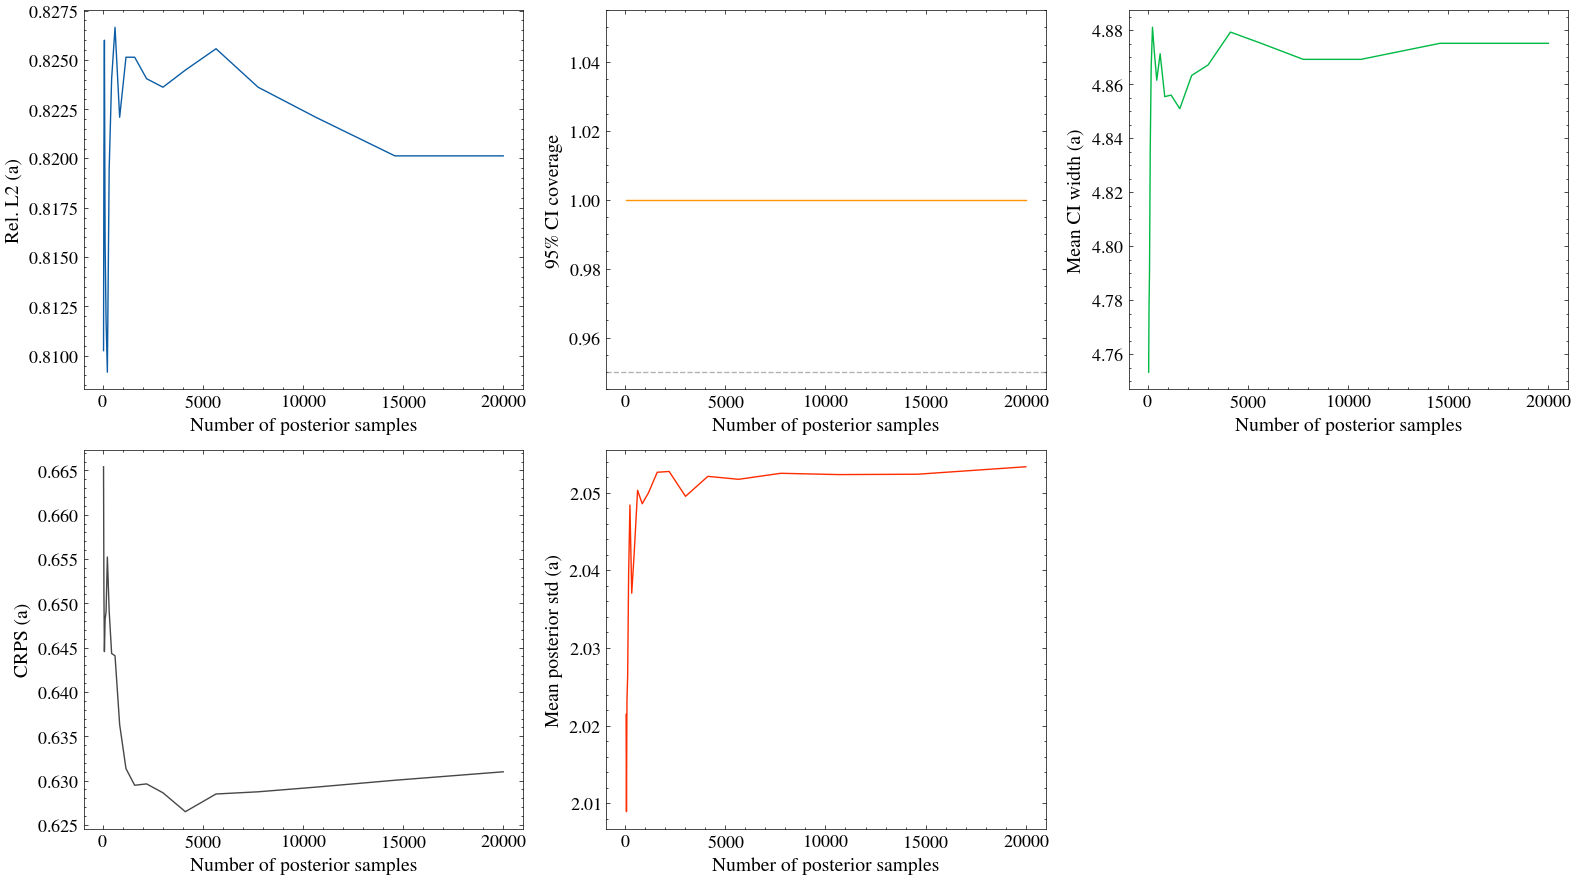

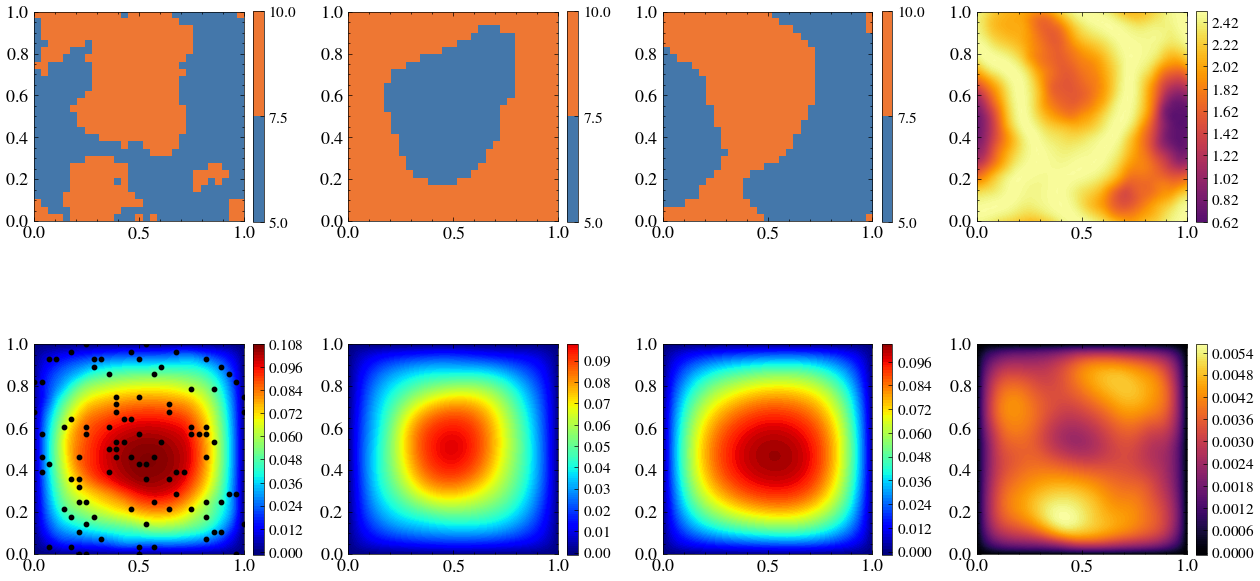

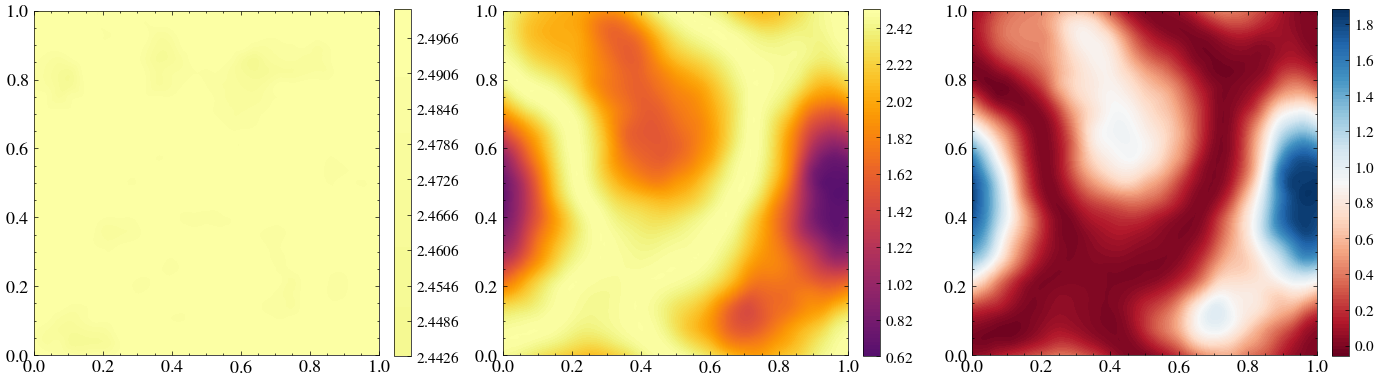

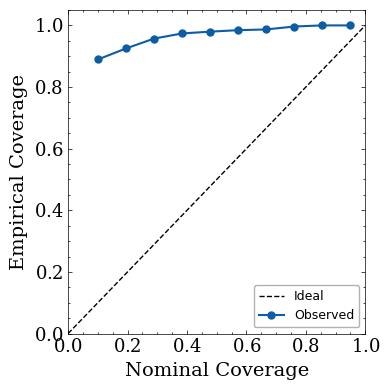

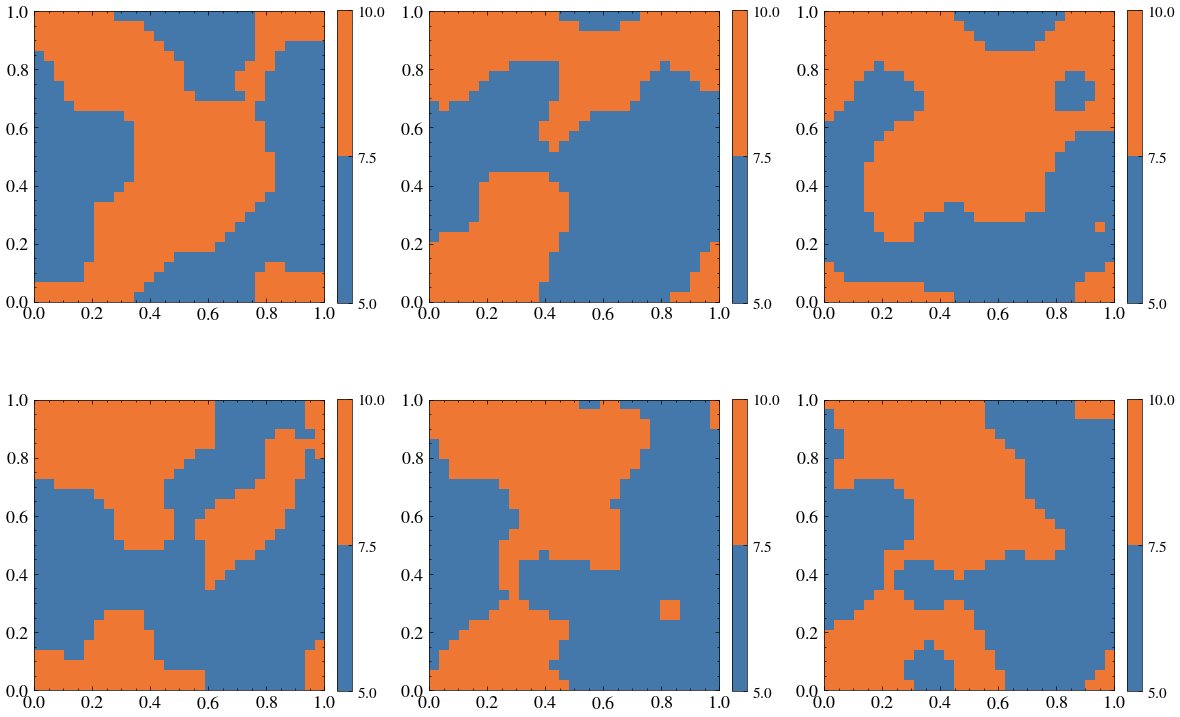

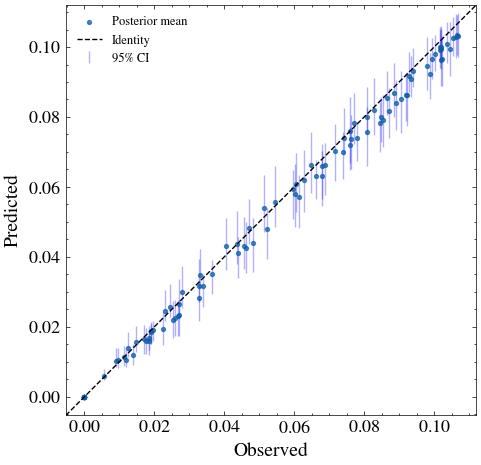

  Chi2 PPC: chi2=3.56, p=1.0000 (df=100)
ESS summary across 200 dimensions (z-space):
  min ESS:    25952.9
  max ESS:    42913.6
  mean ESS:   38228.2
  median ESS: 38641.5
  dims with ESS < 10: 0 / 200
  dims with ESS < 50: 0 / 200

R-hat summary (z-space):
  max R-hat:  1.0001
  mean R-hat: 0.9999
  dims with R-hat > 1.1: 0 / 200
  dims with R-hat > 1.05: 0 / 200

Worst 10 dimensions by ESS (z-space):
 dim       ESS     R-hat        mean         std
 125   25952.9    0.9999      0.5994      0.1206
 116   28512.8    0.9999      0.4875      0.1473
 145   29528.9    0.9999      0.6289      0.1307
 157   29819.1    0.9999      0.5891      0.1311
 113   29899.8    0.9999      0.4345      0.1508
 153   30542.9    0.9999      0.4584      0.1427
 151   31296.2    0.9998      0.4286      0.1492
 198   31927.3    1.0000      0.5632      0.1400
 131   32957.6    0.9999      0.5080      0.1498
 150   33770.5    0.9999      0.5022      0.1493

Divergences: 2 / 20000 (0.0%)

  RELIABILITY: [PASS]

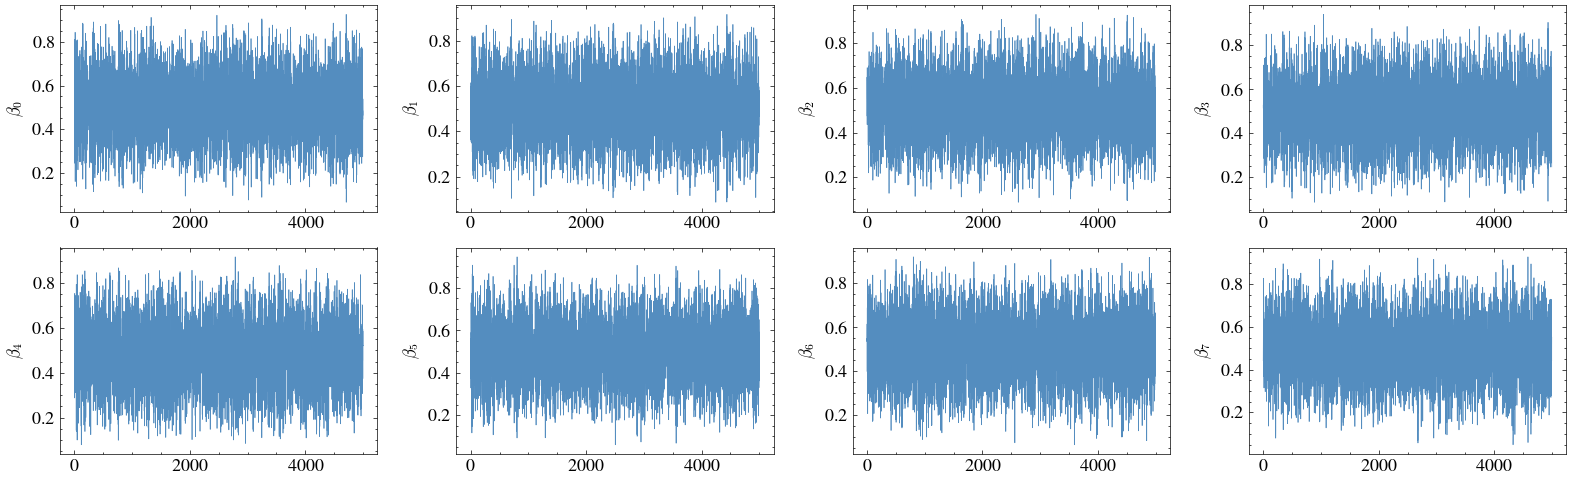

In [6]:
NUM_WARMUP = 15000
NUM_SAMPLES = 5000
NUM_CHAINS = 4
CHAIN_METHOD = 'sequential'

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"SEED = {SEED}")
    print(f"{'='*60}")

    _t_total_start = time.time()

    FIGURE_DIR = Path(f'figures/baseline_darcy_piecewise_5v10/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    # ### Observations (this seed)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)

    obs_data = problem.prepare_observations(
        sample_indices=[TEST_IDX],
        obs_indices=obs_indices,
    )

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]

    print(f"x_obs: {x_obs.shape}, u_obs: {u_obs.shape}")
    print(f"a_true range: [{float(a_true.min()):.1f}, {float(a_true.max()):.1f}] (expect {{5, 10}})")

    # ### Prior Predictive Baseline

    a_true_np = np.array(a_true[0, :, 0])
    def _prior_icorr(pred, true):
        pred_thresh = np.where(np.array(pred) >= 7.5, 10.0, 5.0)
        return float(cross_correlation(jnp.array(pred_thresh), jnp.array(true)))
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
        error_fn=_prior_icorr,
    )
    prior_a_std = np.std(prior_a_samples, axis=0)
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}, "
          f"CI_width={prior_metrics['ci_width']:.4f}, mean_std={prior_metrics['mean_std']:.4f}")

    # ### Log-likelihood and NF reparameterized model

    log_likelihood_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs)

    nf_model_fn = make_nf_reparameterized_model(
        nf_model=problem.models['nf'],
        nf_params=params['nf'],
        log_likelihood_fn=log_likelihood_fn,
        d=d,
        nf_alpha=NF_ALPHA,
    )

    # ### MAP Baseline

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = rmse(a_map, a_true[0])
    rmse_map_u = rmse(u_map, u_true[0])
    icorr_map = cross_correlation(a_map, a_true[0])
    print(f"\nMAP RMSE: a={rmse_map_a:.6f}, u={rmse_map_u:.6f}")
    print("  (Note: RMSE is meaningless for piecewise constant fields — use I_corr instead)")
    print(f"MAP I_corr: {icorr_map:.6f}")

    from src.utils.PlotFigure import Plot
    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (x{inv_config.loss_weights.pde})', f'Data (x{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Full MCMC Run

    preds_map_at_obs = problem.predict_from_beta(params, beta_map, x_obs)
    u_pred_map_at_obs = preds_map_at_obs['u_pred']
    SIGMA = compute_sigma_from_map(u_pred_map_at_obs, u_obs)
    print(f"sigma (MAP residual): {SIGMA:.6f}")

    print(f"Running NUTS (NF reparameterized): {NUM_WARMUP} warmup, {NUM_SAMPLES} samples, {NUM_CHAINS} chains ({CHAIN_METHOD}), sigma={SIGMA}")
    print("WARNING: 200-dim latent space. NF reparameterization should improve mixing vs beta-space.")

    nuts_cfg = recommended_nuts_config(d, SIGMA)
    print(f"NUTS config: target_accept_prob={nuts_cfg['target_accept_prob']}, max_tree_depth={nuts_cfg['max_tree_depth']}")

    rng, mcmc_key = random.split(rng)
    mcmc, timing = run_mcmc(
        functools.partial(nf_model_fn, sigma=SIGMA),
        {"z": z_init}, {}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )

    mcmc.print_summary(exclude_deterministic=True)

    diag = extract_mcmc_diagnostics(mcmc, sample_name="z", total_samples=NUM_CHAINS * NUM_SAMPLES)

    # Get z samples and convert to beta via NF inverse
    z_01_samples = mcmc.get_samples()["z"]
    z_samples = 2.0 * z_01_samples - 1.0
    beta_samples, _ = problem.models['nf'].apply(
        {'params': params['nf']}, z_samples, method=problem.models['nf'].inverse
    )
    print(f"z samples shape: {z_01_samples.shape}")
    print(f"Beta samples shape: {beta_samples.shape}")

    # ### Decode Posterior Samples (inline sigmoid decode for piecewise)

    n_samples = beta_samples.shape[0]

    DECODE_BATCH = 500
    a_pred_list = []
    u_pred_list = []

    for i in range(0, n_samples, DECODE_BATCH):
        batch = beta_samples[i:i+DECODE_BATCH]
        bs = batch.shape[0]
        x_tile = jnp.tile(x_full, (bs, 1, 1))

        u_pred = problem.models['u'].apply({'params': params['u']}, x_tile, batch)
        if u_pred.ndim == 2:
            u_pred = u_pred[..., None]
        u_pred = mollifier(u_pred.squeeze(-1), x_tile)
        u_pred_list.append(u_pred)

        a_logits = problem.models['a'].apply({'params': params['a']}, x_tile, batch)
        a_prob = jax.nn.sigmoid(a_logits)
        a_decoded = a_sample(a_prob[..., None], k_low=problem.K_LOW, k_high=problem.K_HIGH)
        a_pred_list.append(a_decoded)

    a_pred_all = jnp.concatenate(a_pred_list, axis=0)
    u_pred_all = jnp.concatenate(u_pred_list, axis=0)

    a_mean = jnp.mean(a_pred_all, axis=0)
    a_std = jnp.std(a_pred_all, axis=0)
    u_mean = jnp.mean(u_pred_all, axis=0)
    u_std = jnp.std(u_pred_all, axis=0)

    print(f"a_pred_all: {a_pred_all.shape}, u_pred_all: {u_pred_all.shape}")

    # ### Metrics

    a_true_np = np.array(a_true[0, :, 0])
    a_mean_np = np.array(a_mean[:, 0])
    a_map_np = np.array(a_map[:, 0])
    a_samples_np = np.array(a_pred_all[:, :, 0])

    u_true_np = np.array(u_true[0, :, 0])
    u_mean_np = np.array(u_mean[:, 0])
    u_map_np = np.array(u_map[:, 0])
    u_samples_np = np.array(u_pred_all[:, :, 0])

    rmse_post_u = rmse(jnp.array(u_mean_np), jnp.array(u_true_np))
    crps_u = float(np.mean(crps_ensemble(u_samples_np, u_true_np)))

    pw_metrics = compute_piecewise_metrics(a_samples_np, a_true_np, 5.0, 10.0, a_err_fn=cross_correlation)
    icorr_post = pw_metrics['a_err']
    crps_a = pw_metrics['crps_a']
    nll_a = pw_metrics['nll_a']
    cal_levels = pw_metrics['cal_levels']
    cal_empirical = pw_metrics['cal_empirical']
    ci_w = pw_metrics['ci_width']
    sharpness = pw_metrics['mean_std']

    a_std_np = np.array(a_std[:, 0])

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np, a_mean_np, a_std_np,
        save_path=FIGURE_DIR / 'error_vs_std.png',
    )
    print(f'Spearman rho(|error|, std) = {spearman_rho:.3f}, p = {spearman_p:.2e}')

    plot_metrics_table({
        'MAP I_corr': icorr_map,
        'Posterior Mean I_corr': icorr_post,
        'CRPS (a)': crps_a,
        'CRPS (u)': crps_u,
        'Mean 95% CI Width (a)': ci_w,
        'Sharpness (mean std)': sharpness,
        'sigma': SIGMA,
    }, title='Darcy Piecewise 5v10 — RQ1 Metrics')

    print("Calibration:")
    for nom, emp in zip(cal_levels, cal_empirical):
        print(f"  Nominal {nom:.0%} -> Empirical {emp:.2%}")

    # ### Statistical Confidence in Metrics

    bs_results = pw_metrics['bootstrap_ci']
    format_significance_table({
        'CRPS (a)':         bs_results['crps_a'],
        'Coverage 95% (a)': bs_results['coverage_95'],
        'CI Width 95% (a)': bs_results['ci_width'],
        'Sharpness (a)':    bs_results['sharpness'],
    }, title='RQ1 — Bootstrap CI on Posterior Metrics (Darcy Piecewise 5v10)')

    chain_metrics = compute_per_chain_metrics(a_samples_np, a_true_np, NUM_CHAINS, k_low=5.0, k_high=10.0, a_err_fn=cross_correlation)
    print_per_chain_table(chain_metrics, NUM_CHAINS)

    # ### Metric Convergence

    conv_result = compute_metric_convergence(a_samples_np, a_true_np, k_low=5.0, k_high=10.0, a_err_fn=cross_correlation)

    from results_schema import ExperimentResult
    from datetime import datetime

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)

    run_result = {
        "sigma": SIGMA,
        "ess_min": diag['ess_min'],
        "rhat_max": diag['rhat_max'],
        "rhat_mean": diag['rhat_mean'],
        "n_div": diag['n_div'],
        "reliability_flag": diag['flag'],
        "reliability_explanation": diag['flag_explanation'],
        "a_err": float(icorr_post),
        "a_err_per_sample": pw_metrics['a_err_per_sample'],
        "u_err": float(rmse_post_u),
        "crps_a": crps_a,
        "nll_a": nll_a,
        "chi2_ppc": chi2_stat,
        "chi2_ppc_pvalue": chi2_pval,
        "coverage_95": float(cal_empirical[-1]),
        "ci_width": float(ci_w),
        "mean_std": sharpness,
        "cal_levels": cal_levels,
        "cal_empirical": cal_empirical,
        "map_a_err": float(icorr_map),
        "map_u_err": float(rmse_map_u),
        "spearman_rho_error_std": spearman_rho,
        "spearman_pvalue_error_std": spearman_p,
        "warmup_time_s": timing['warmup_time_s'],
        "sampling_time_s": timing['sampling_time_s'],
        "step_time_s": timing['step_time_s'],
    }

    mcmc_result = build_mcmc_result(run_result, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="baseline",
        problem="darcy_piecewise_5v10",
        experiment_type="single",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        test_idx=TEST_IDX,
        condition=mcmc_result,
        prior=build_prior_result(prior_metrics),
        laplace=None,
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    plot_metric_convergence(
        [conv_result],
        save_path=FIGURE_DIR / 'metric_convergence.png',
    )

    # ### Plots

    x_np = np.array(x_full[0])

    plot_field_comparison(
        x_np, a_true_np, a_map_np, a_mean_np, a_std_np,
        grid_shape=(29, 29),
        u_true=u_true_np, u_map=u_map_np, u_mean=u_mean_np, u_std=np.array(u_std[:, 0]),
        obs_coords=np.array(x_obs[0]),
        save_path=FIGURE_DIR / 'field_comparison.png',
        show_abs_error=False,
        piecewise_a_bounds=(5.0, 10.0),
    )

    plot_std_comparison_generic(
        x_np, prior_a_std, a_std_np,
        label_a='Prior', label_b='Posterior',
        grid_shape=(29, 29),
        suptitle='Prior vs Posterior Uncertainty',
        save_path=FIGURE_DIR / 'prior_posterior_std.png',
    )

    plot_calibration(cal_levels, cal_empirical, save_path=FIGURE_DIR / 'calibration.png')

    plot_posterior_gallery(
        x_np, a_samples_np, grid_shape=(29, 29),
        piecewise_a_bounds=(5.0, 10.0),
        a_true=a_true_np, n_show=6,
        save_path=FIGURE_DIR / 'posterior_gallery.png',
    )

    u_pred_at_obs = u_samples_np[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    plot_posterior_predictive(
        u_obs_np, u_pred_at_obs,
        obs_label='u observed',
        save_path=FIGURE_DIR / 'posterior_predictive.png',
    )

    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, SIGMA)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

    # ### MCMC Diagnostics (Appendix)

    z_np = np.array(z_01_samples)
    ess_np = np.array(diag['ess'])
    rhat_np = np.array(diag['rhat'])
    d_diag = diag['by_chain'].shape[-1]

    print(f"ESS summary across {d_diag} dimensions (z-space):")
    print(f"  min ESS:    {float(ess_np.min()):.1f}")
    print(f"  max ESS:    {float(ess_np.max()):.1f}")
    print(f"  mean ESS:   {float(ess_np.mean()):.1f}")
    print(f"  median ESS: {float(np.median(ess_np)):.1f}")
    print(f"  dims with ESS < 10: {int((ess_np < 10).sum())} / {d_diag}")
    print(f"  dims with ESS < 50: {int((ess_np < 50).sum())} / {d_diag}")

    print(f"\nR-hat summary (z-space):")
    print(f"  max R-hat:  {float(rhat_np.max()):.4f}")
    print(f"  mean R-hat: {float(rhat_np.mean()):.4f}")
    print(f"  dims with R-hat > 1.1: {int((rhat_np > 1.1).sum())} / {d_diag}")
    print(f"  dims with R-hat > 1.05: {int((rhat_np > 1.05).sum())} / {d_diag}")

    worst_dims = np.argsort(ess_np)[:10]
    print(f"\nWorst 10 dimensions by ESS (z-space):")
    print(f"{'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
    for dim in worst_dims:
        print(f"{dim:4d}  {float(ess_np[dim]):8.1f}  {float(rhat_np[dim]):8.4f}  {float(z_np[:, dim].mean()):10.4f}  {float(z_np[:, dim].std()):10.4f}")

    extra_fields = mcmc.get_extra_fields()
    if "diverging" in extra_fields:
        n_div = int(extra_fields["diverging"].sum())
        total = NUM_CHAINS * NUM_SAMPLES
        print(f"\nDivergences: {n_div} / {total} ({n_div/total:.1%})")
    else:
        print("\nDivergence info not available")

    print(f"\n  RELIABILITY: [{diag['flag']}] {diag['flag_explanation']}")

    z_all_chains = np.array(mcmc.get_samples(group_by_chain=True)["z"])
    z_for_trace = z_all_chains[0]
    plot_trace(z_for_trace[:, :8], beta_true=None, num_warmup=0, save_path=FIGURE_DIR / 'trace_plots_first8.png')

## Cross-Seed Aggregation Summary

In [7]:
print_cross_seed_summary("baseline", "darcy_piecewise_5v10")

Cross-Seed Summary (10 seeds: [7, 7, 7, 42, 42, 42, 42, 123, 123, 123])

Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.8097      0.0813      0.6745      0.8968
u_err                 0.0448      0.0082      0.0326      0.0521
crps_a                0.6575      0.1548      0.4763      0.9127
coverage_95           0.9998      0.0008      0.9976      1.0000
ci_width              4.8621      0.0512      4.8038      4.9526
mean_std              1.9886      0.0576      1.9091      2.0533
ess_min           22007.4123   3449.2270  16534.1359  25952.8884
rhat_max              1.0002      0.0001      1.0001      1.0003
n_div                10.5000     12.0853      1.0000     31.0000
